In [1]:
# appV23.0 Rev 32 (Blok 1 - Audit & Stratified Split)

import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

dataset_path = '/kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset'
selected_classes = ['angry', 'happy', 'sad', 'neutral']

# Cek path dinamis jika sewaktu-waktu struktur direktori Kaggle bergeser
if not os.path.exists(dataset_path):
    print(f"[PERINGATAN] Path meleset. Menjalankan pelacak otomatis...")
    for root, dirs, files in os.walk('/kaggle/input/'):
        if 'fane_data' in dirs or all(cls in dirs for cls in selected_classes):
            dataset_path = root
            break

print(f"-> Lokasi aktif dataset: {dataset_path}")
print("-> Memindai dan membuang file gambar rusak...")

all_paths, all_labels = [], []
corrupted_count = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            folder_parts = root.lower().split(os.sep)
            for cls in selected_classes:
                if cls in folder_parts:
                    full_path = os.path.join(root, file)
                    try:
                        # Verifikasi fisik integritas file gambar
                        with Image.open(full_path) as img:
                            img.verify() 
                        all_paths.append(full_path)
                        all_labels.append(cls)
                    except Exception:
                        corrupted_count += 1
                    break

print(f"-> Selesai! {corrupted_count} file rusak berhasil dibuang dari pipa latihan.")

df_raw = pd.DataFrame({'filename': all_paths, 'label': all_labels})
if df_raw.empty: 
    raise ValueError("[ERROR] Dataset kosong atau tidak terbaca! Periksa kembali dataset input Anda.")

# Membagi data 80% Train, 20% Val dengan teknik stratifikasi agar seimbang
train_df, val_df = train_test_split(df_raw, test_size=0.2, stratify=df_raw['label'], random_state=42)

print("\n=======================================================")
print(f" DATA TRAIN (BELAJAR): {len(train_df)} foto")
print(f" DATA TEST (UJIAN)   : {len(val_df)} foto")
print("=======================================================")

-> Lokasi aktif dataset: /kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset
-> Memindai dan membuang file gambar rusak...
-> Selesai! 1 file rusak berhasil dibuang dari pipa latihan.

 DATA TRAIN (BELAJAR): 6609 foto
 DATA TEST (UJIAN)   : 1653 foto


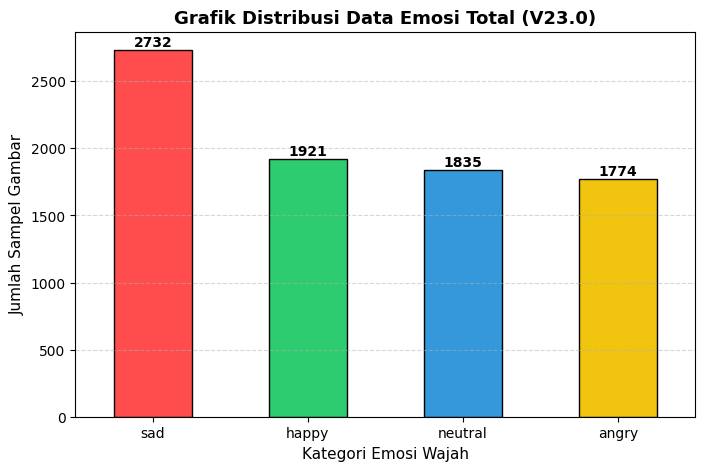

In [2]:
# appV23.0 Rev 32 (Blok 2 - Visualisasi Data)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
warna_grafik = ['#ff4d4d', '#2ecc71', '#3498db', '#f1c40f'] 

df_raw['label'].value_counts().plot(kind='bar', color=warna_grafik, edgecolor='black')
plt.title('Grafik Distribusi Data Emosi Total (V23.0)', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Emosi Wajah', fontsize=11)
plt.ylabel('Jumlah Sampel Gambar', fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(df_raw['label'].value_counts()):
    plt.text(i, v + (df_raw['label'].value_counts().max() * 0.01), str(v), ha='center', fontweight='bold')

plt.show()

In [3]:
# appV23.0 Rev 32 (Blok 3 - Data Pipeline & Extreme Augmentation)

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from sklearn.utils.class_weight import compute_class_weight

print("-> Mengonfigurasi Generator dengan Anti-Backlight & Zoom (224x224)...")

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    rotation_range=15,       
    width_shift_range=0.15,                   
    height_shift_range=0.15,                  
    zoom_range=0.2, # AI dipaksa melihat lebih dekat ke bibir/mata                      
    brightness_range=[0.6, 1.4], # Trik utama: Membiasakan AI dengan foto gelap & terang (seperti webcam)
    horizontal_flip=True                     
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='label',
    target_size=(224, 224), color_mode='rgb', batch_size=32,
    class_mode='categorical', classes=selected_classes, shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filename', y_col='label',
    target_size=(224, 224), color_mode='rgb', batch_size=32,
    class_mode='categorical', classes=selected_classes, shuffle=False
)

kelas_unik = np.unique(train_generator.classes)
bobot_kelas = compute_class_weight('balanced', classes=kelas_unik, y=train_generator.classes)
class_weight_dict = dict(enumerate(bobot_kelas))

print("\n-> [INFO] Bobot Kelas Matematika Aktif:")
for cls_name, idx in train_generator.class_indices.items():
    print(f"   - {cls_name.upper()}: Bobot {class_weight_dict[idx]:.2f}x")

2026-06-30 09:53:58.775758: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782813238.799028     980 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782813238.807232     980 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782813238.826862     980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782813238.826884     980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782813238.826886     980 computation_placer.cc:177] computation placer alr

-> Mengonfigurasi Generator dengan Anti-Backlight & Zoom (224x224)...
Found 6609 validated image filenames belonging to 4 classes.
Found 1653 validated image filenames belonging to 4 classes.

-> [INFO] Bobot Kelas Matematika Aktif:
   - ANGRY: Bobot 1.16x
   - HAPPY: Bobot 1.07x
   - SAD: Bobot 0.76x
   - NEUTRAL: Bobot 1.13x


In [4]:
# appV23.0 Rev 32 (Blok 4 - ResNet50V2 Deep Fine-Tuning)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50V2

print("-> Membangun Model ResNet50V2 (Deep Fine-Tuning)...")

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# BUKA LEBIH BANYAK LAYER: Kita unfreeze 60 layer terakhir agar AI bisa mengenali detail kacamata vs mata asli
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),                             
    Dense(256, activation='relu'), 
    BatchNormalization(),                                 
    Dropout(0.55), # Dropout dinaikkan sedikit ke 55% karena layer yang dibuka lebih banyak                                    
    Dense(4, activation='softmax')                        
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.15), # Label smoothing dinaikkan agar AI tidak kaku
    metrics=['accuracy']
)

model.summary()

-> Membangun Model ResNet50V2 (Deep Fine-Tuning)...


I0000 00:00:1782813242.133082     980 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782813242.138475     980 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,091,396 (91.90 MB)

 Trainable params: 17,733,380 (67.65 MB)

 Non-trainable params: 6,358,016 (24.25 MB)


-> Memulai proses kalkulasi model pembelajaran...
Epoch 1/60


I0000 00:00:1782813257.467840    1051 service.cc:152] XLA service 0x7852d4002530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782813257.467877    1051 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782813257.467882    1051 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782813260.021675    1051 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/206 ━━━━━━━━━━━━━━━━━━━━ 1:34:15 28s/step - accuracy: 0.1562 - loss: 2.6053

I0000 00:00:1782813272.441504    1051 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


206/206 ━━━━━━━━━━━━━━━━━━━━ 126s 481ms/step - accuracy: 0.4431 - loss: 1.8057 - val_accuracy: 0.5705 - val_loss: 1.2063 - learning_rate: 1.0000e-04
Epoch 2/60
  1/206 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.5000 - loss: 1.4977

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5000 - loss: 1.4977 - val_accuracy: 0.5711 - val_loss: 1.2043 - learning_rate: 1.0000e-04
Epoch 3/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 83s 402ms/step - accuracy: 0.5198 - loss: 1.4827 - val_accuracy: 0.6587 - val_loss: 1.1278 - learning_rate: 1.0000e-04
Epoch 4/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5938 - loss: 1.4760 - val_accuracy: 0.6642 - val_loss: 1.1286 - learning_rate: 1.0000e-04
Epoch 5/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 82s 399ms/step - accuracy: 0.5709 - loss: 1.3126 - val_accuracy: 0.6507 - val_loss: 1.1358 - learning_rate: 1.0000e-04
Epoch 6/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3750 - loss: 1.4329 - val_accuracy: 0.6538 - val_loss: 1.1301 - learning_rate: 1.0000e-04
Epoch 7/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 84s 406ms/step - accuracy: 0.6082 - loss: 1.1702 - val_accuracy: 0.6869 - val_loss: 1.1527 - learning_rate: 1.0000e-04
Epoch 8/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy

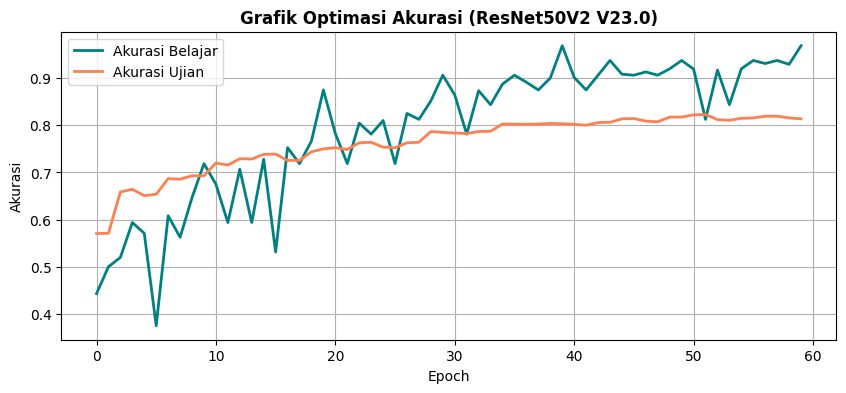

In [5]:
# appV23.0 Rev 32 (Blok 5 - Training Phase)

import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

epochs = 60

print("\n-> Memulai proses kalkulasi model pembelajaran...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    class_weight=class_weight_dict, 
    callbacks=[early_stop, reduce_lr]
)

total_loss, total_accuracy = model.evaluate(val_generator, verbose=1)

print("\n=======================================================")
print("             HASIL EVALUASI FINAL RESNET (v23.0)       ")
print("=======================================================")
print(f" > LOSS AKHIR MODEL    : {total_loss:.4f}")
print(f" > AKURASI REAL MODEL  : {total_accuracy * 100:.2f} %")
print("=======================================================")

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Akurasi Belajar', color='teal', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Akurasi Ujian', color='coral', linewidth=2)
plt.title('Grafik Optimasi Akurasi (ResNet50V2 V23.0)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# appV23.0 Rev 32 (Blok 6 - UI Upload Gambar)

import ipywidgets as widgets
from IPython.display import display

print("=========================================================")
print("             LANGKAH 1: UNGGAH FOTO WAJAH ANDA           ")
print("=========================================================")

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

print("\n[PETUNJUK]: Jika file sudah terunggah sempurna, silakan langsung jalankan Blok 7.")

             LANGKAH 1: UNGGAH FOTO WAJAH ANDA           


FileUpload(value=(), accept='image/*', description='Upload')


[PETUNJUK]: Jika file sudah terunggah sempurna, silakan langsung jalankan Blok 7.


             LANGKAH 2: EKSEKUSI PREDIKSI                
-> [SUKSES] Area wajah berhasil di-crop SANGAT KETAT!


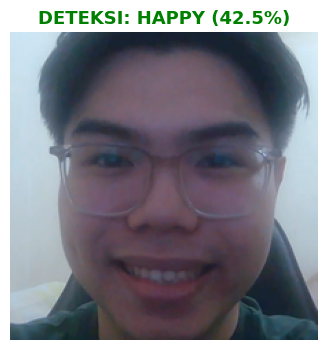


Rincian Tingkat Keyakinan Prediksi AI:
- Angry: 6.87%
- Happy: 42.54%
- Sad: 34.44%
- Neutral: 16.14%


In [27]:
# appV23.0 Rev 32 (Blok 7 - Eksekusi Prediksi & TIGHT Cropping)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet_v2 import preprocess_input

print("=========================================================")
print("             LANGKAH 2: EKSEKUSI PREDIKSI                ")
print("=========================================================")

if 'model' not in locals():
    print("[ERROR] Model belum terbuat. Selesaikan Blok 4 & 5 terlebih dahulu.")
elif not uploader.value:
    print("[ERROR] Anda belum mengunggah foto di Blok 6!")
else:
    if isinstance(uploader.value, dict):
        filename = list(uploader.value.keys())[0]
        content = uploader.value[filename]['content']
    else:
        content = uploader.value[0]['content'] if isinstance(uploader.value[0], dict) else uploader.value[0].content
        
    img_array_orig = np.frombuffer(content, np.uint8)
    img_cv = cv2.imdecode(img_array_orig, cv2.IMREAD_COLOR)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)
    
    # Deteksi dibuat lebih sensitif
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=6, minSize=(60, 60))

    if len(faces) == 0:
        print("[INFO] Wajah tidak terdeteksi OpenCV, menganalisis gambar secara utuh...")
        face_img = img_cv
    else:
        x, y, w, h = faces[0]
        # PERBAIKAN: Padding proporsional (Tight Crop). Hanya mengambil 10% sisa ruang agar bahu hilang.
        pad_y = int(h * 0.10)
        pad_x = int(w * 0.10)
        
        y1, y2 = max(0, y - pad_y), min(img_cv.shape[0], y + h + pad_y)
        x1, x2 = max(0, x - pad_x), min(img_cv.shape[1], x + w + pad_x)
        face_img = img_cv[y1:y2, x1:x2]
        print("-> [SUKSES] Area wajah berhasil di-crop SANGAT KETAT!")

    img_pil = Image.fromarray(face_img).resize((224, 224), Image.LANCZOS)
    img_array = image.img_to_array(img_pil)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array) 
    
    predictions = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(predictions[0]) 
    pred_emo = selected_classes[pred_idx]
    conf = predictions[0][pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil) 
    plt.title(f"DETEKSI: {pred_emo.upper()} ({conf:.1f}%)", fontsize=13, fontweight='bold', color='green' if pred_emo=='happy' else 'black')
    plt.axis('off')
    plt.show()

    print("\nRincian Tingkat Keyakinan Prediksi AI:")
    for i, cls in enumerate(selected_classes):
        print(f"- {cls.capitalize()}: {predictions[0][i]*100:.2f}%")

In [28]:
# appV23.0 Rev 32 (Blok 8 - Export TFLite & H5)

import tensorflow as tf
from IPython.display import FileLink, display

print("=========================================================")
print("             LANGKAH 3: EKSPOR MODEL PRODUKSI            ")
print("=========================================================")

if 'model' not in locals():
    print("[ERROR] Variabel 'model' tidak ditemukan untuk diekspor.")
else:
    print("-> Mengonversi model untuk sistem Android (TFLite)...")
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    
    # Kuantisasi default untuk mereduksi ukuran file model tanpa merusak akurasi
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()

    with open("model_emosi_android.tflite", "wb") as f:
        f.write(tflite_model)

    print("-> Menyimpan model untuk sistem Web/Backend (.h5)...")
    model.save("model_emosi_web.h5")

    print("\n[SUKSES] EKSPOR SELESAI! KLIK LINK DI BAWAH UNTUK UNDUH")
    print("---------------------------------------------------------")
    print("Model Android Ringan (.tflite):")
    display(FileLink('model_emosi_android.tflite'))

    print("\nModel Website (.h5):")
    display(FileLink('model_emosi_web.h5'))

             LANGKAH 3: EKSPOR MODEL PRODUKSI            
-> Mengonversi model untuk sistem Android (TFLite)...
INFO:tensorflow:Assets written to: /tmp/tmpojogauok/assets


INFO:tensorflow:Assets written to: /tmp/tmpojogauok/assets


Saved artifact at '/tmp/tmpojogauok'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_190')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132303213872912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213875792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213876560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213876752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213875024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213876176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213875216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213879248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213879440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132303213878672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1323032138

W0000 00:00:1782816353.539877     980 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782816353.539942     980 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1782816353.706364     980 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


-> Menyimpan model untuk sistem Web/Backend (.h5)...

[SUKSES] EKSPOR SELESAI! KLIK LINK DI BAWAH UNTUK UNDUH
---------------------------------------------------------
Model Android Ringan (.tflite):


/kaggle/working/model_emosi_android.tflite


Model Website (.h5):


/kaggle/working/model_emosi_web.h5